In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mne.filter import filter_data

### COnfig

In [16]:
CHANNEL_NAMES = [
    "FP1",
    "F3",
    "F7",
    "C3",
    "T3",
    "P3",
    "T5",
    "O1",
    "FP2",
    "F4",
    "F8",
    "C4",
    "T4",
    "P4",
    "T6",
    "O2"
]

#### Load data

In [7]:
# Loading EEG
df_eeg = pd.read_csv("../data/subjectV/V_eeg_20260617_150226.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG = df_eeg.iloc[:, 1:-1].values
button = df_eeg.iloc[:, -1].values.astype(bool)

N_CHANNELS = EEG.shape[1]
FS = 250. # Sampling frequency

## Go/No-Go Task (`scripts/gng_task.py`)

PyGame + LSL experiment for motor intention data collection.

**Run:**
```bash
python scripts/gng_task.py --out-dir data/gng --prefix S01
```

Outputs two CSVs per session: `<prefix>_markers_<datetime>.csv` and `<prefix>_eeg_<datetime>.csv`.

### LSL Marker Codes

| Code | Label | Meaning |
|------|-------|---------|
| 5 | `S1_warning` | S1 warning cue onset |
| 10 | `go_onset` | Go stimulus (S2) onset |
| 20 | `nogo_onset` | No-Go stimulus (S2) onset |
| 30 | `button_press` | Button press detected |
| 11 | `hit` | Go + pressed in time |
| 12 | `miss` | Go + no press |
| 21 | `correct_rejection` | No-Go + no press |
| 22 | `false_alarm` | No-Go + pressed |
| 99 | `end` | Experiment end |


In [8]:
# Loading markers
df_markers = pd.read_csv("../data/subjectV/V_markers_20260617_150226.csv")

### Preprocess EEG

In [9]:
EEG = filter_data(EEG.T[None], 250, .5, 28., verbose=False).squeeze()

### Check evoked potentials

In [24]:
WINDOW = 1.5
N_SAMPLES = int(WINDOW * FS) + 1  # fixed epoch length
T_ARRAY = np.arange(0, WINDOW + 1 / FS, 1 / FS)

In [37]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []

for onset in go_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    GO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

GO_ERP = np.stack(GO_ERP)


In [38]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []

for onset in nogo_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    NOGO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

NOGO_ERP = np.stack(NOGO_ERP)

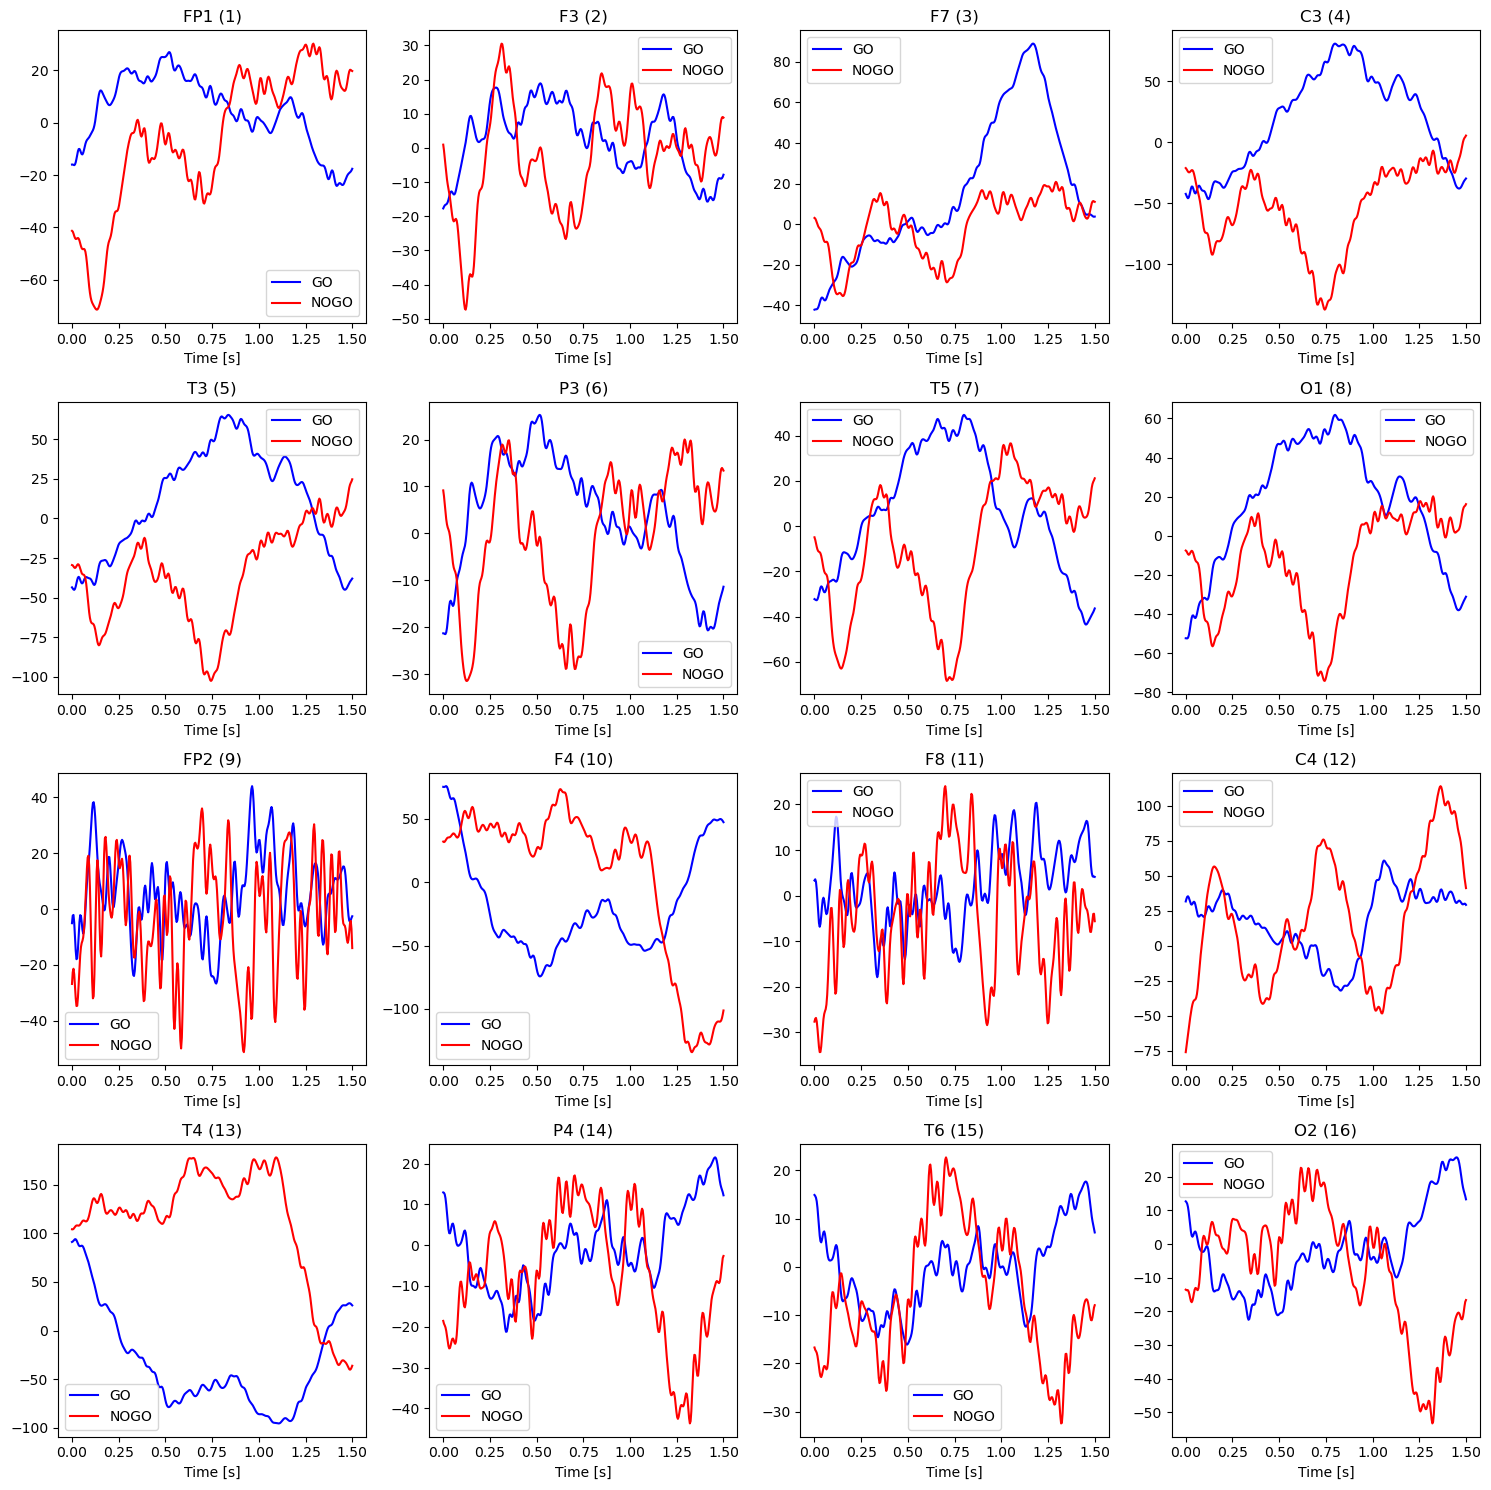

In [49]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot( T_ARRAY, GO_ERP.mean(0)[pos], "b" , label="GO") 
    plt.plot( T_ARRAY, NOGO_ERP.mean(0)[pos], "r"  , label="NOGO") 
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [50]:
NOGO_MEAN = NOGO_ERP.mean(axis=0)            # (16, 376)
GO_ERP_corrected = GO_ERP.mean(axis=0) - NOGO_MEAN  # (16, 376)

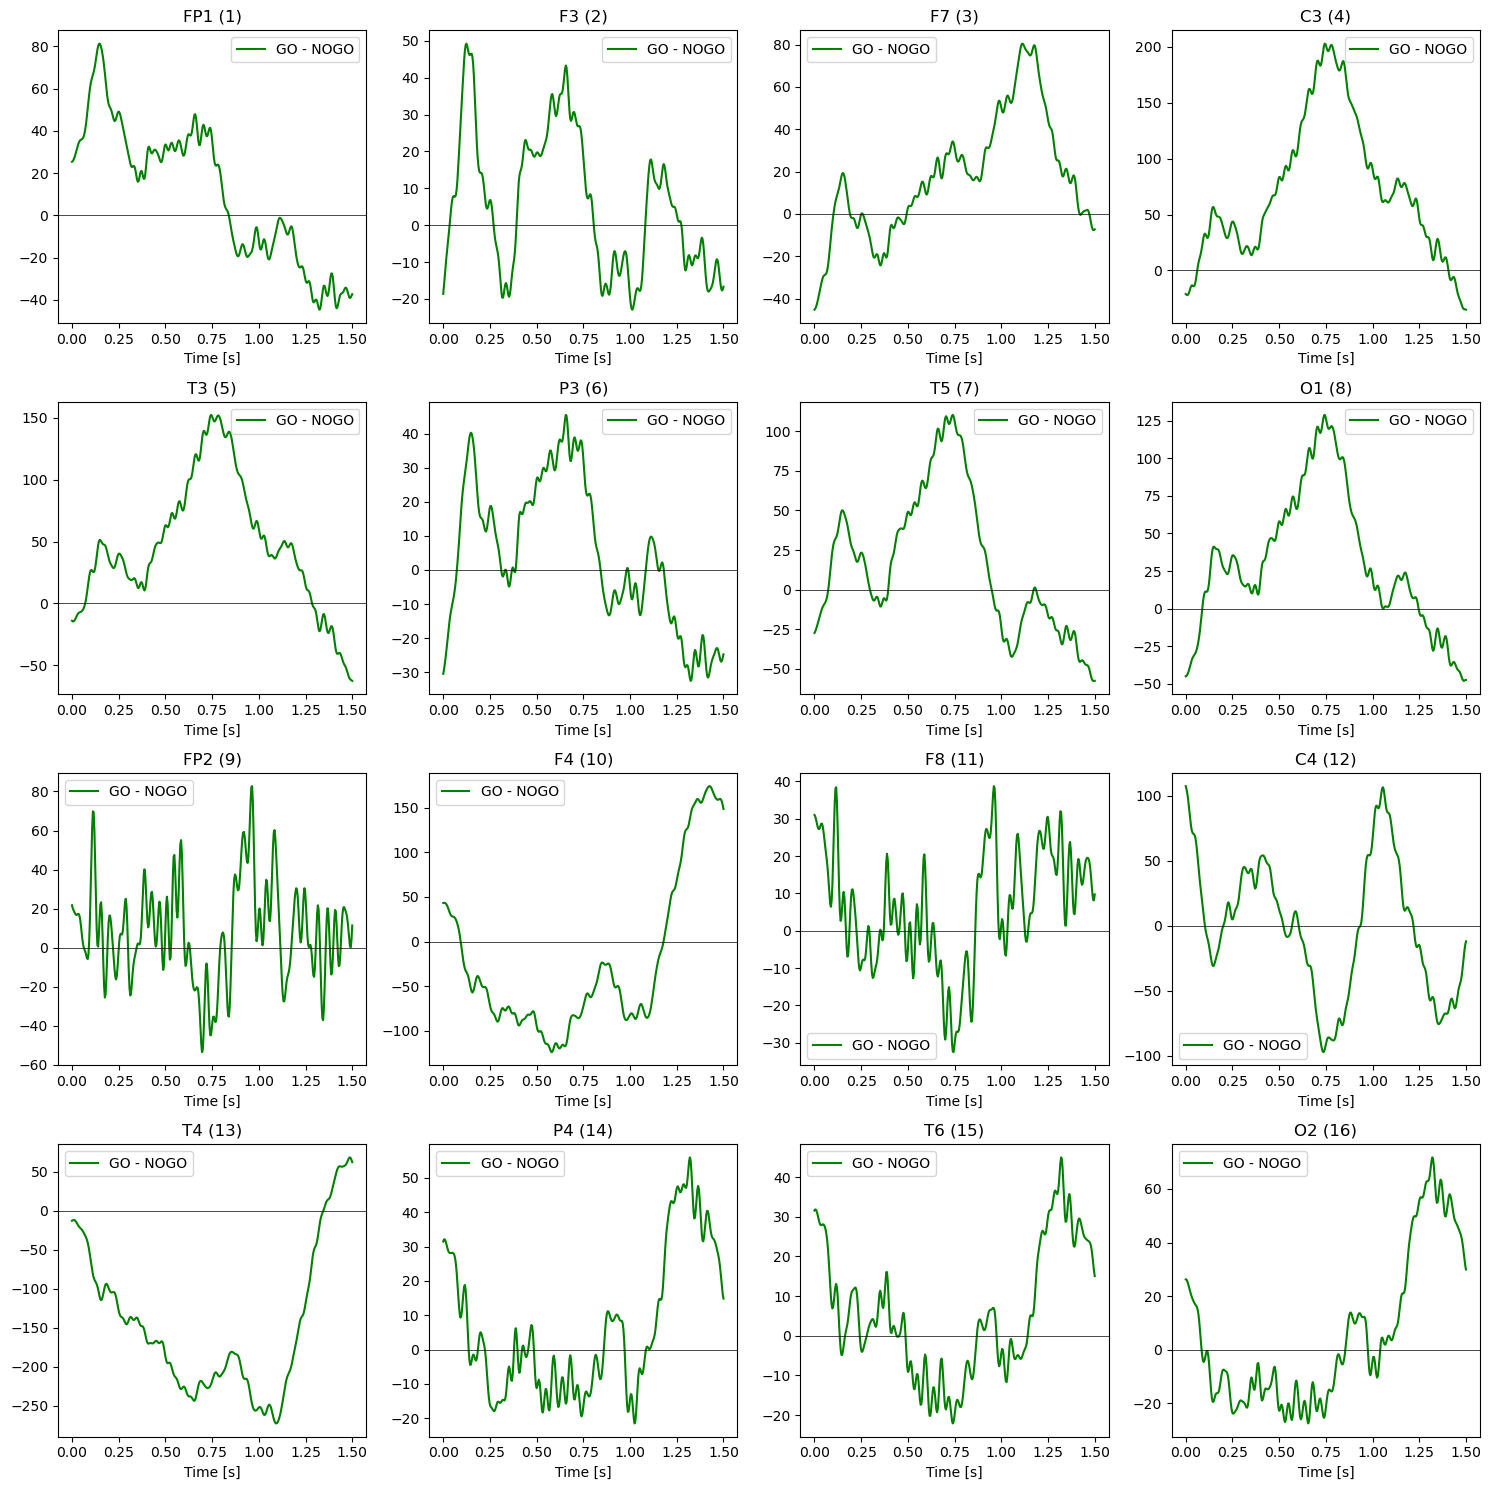

In [51]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_ARRAY, GO_ERP_corrected[pos], "g", label="GO - NOGO")
    plt.axhline(0, color="k", linewidth=0.5)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [52]:
df_markers

,lsl_timestamp,marker_code,marker_label,trial_type
0,466008.759979,10,go_onset,go
1,466009.332796,30,button_press,go
2,466009.332814,11,hit,go
3,466012.490934,10,go_onset,go
4,466014.493650,12,miss,go
...,...,...,...,...
270,466372.029289,11,hit,go
271,466374.504777,10,go_onset,go
272,466375.125870,30,button_press,go
273,466375.125888,11,hit,go
